# ch192 — Rank, Nullity, and the Fundamental Theorem of Linear Algebra

> **Prerequisites:** ch151–ch161 (Matrices through Gaussian Elimination), ch145 (Basis and Dimension), ch173 (SVD)
> **You will learn:**
> - What rank and nullity measure about a matrix
> - The four fundamental subspaces of a matrix
> - The Rank-Nullity theorem: rank(A) + nullity(A) = n
> - How SVD makes the four subspaces explicit
> - Why these concepts govern solvability of Ax = b
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Every matrix $A \in \mathbb{R}^{m \times n}$ defines a linear map $f: \mathbb{R}^n \to \mathbb{R}^m$. That map compresses some directions to zero (the null space) and maps others to a subspace of $\mathbb{R}^m$ (the column space). The **rank** of $A$ is the dimension of its image — how many directions survive the transformation. The **nullity** is the dimension of its kernel — how many directions are annihilated.

The **Rank-Nullity theorem** states: $\text{rank}(A) + \text{nullity}(A) = n$ (number of columns). This is a conservation law: the total dimensionality of the input space is split exactly between the subspace that gets mapped somewhere and the subspace that gets mapped to zero.

Common misconceptions:
- Rank is not determined by size. A $1000 \times 1000$ matrix can have rank 1.
- Full rank does not mean the matrix is square.
- The null space is not just the zero vector — it is a subspace.

## 2. Intuition & Mental Models

**Geometric:** Think of a matrix as a lens that compresses a 3D space into 2D. The image is 2D (rank 2). Everything in the plane perpendicular to the lens axis maps to zero (nullity 1). The total is 3 = rank + nullity.

**Computational:** The rank is the number of non-zero singular values *(ch173 — SVD)*. The null space is spanned by the right singular vectors corresponding to zero singular values. SVD makes these subspaces explicit.

**The four fundamental subspaces** (Gilbert Strang's formulation):
- Column space of $A$: image of $\mathbb{R}^n$ under $A$
- Null space of $A$: kernel of $A$
- Row space of $A^\top$: directions that survive in input space
- Left null space of $A^\top$: directions in output space orthogonal to column space

These four subspaces are orthogonal in pairs and together span the full input and output spaces.

## 3. Visualization

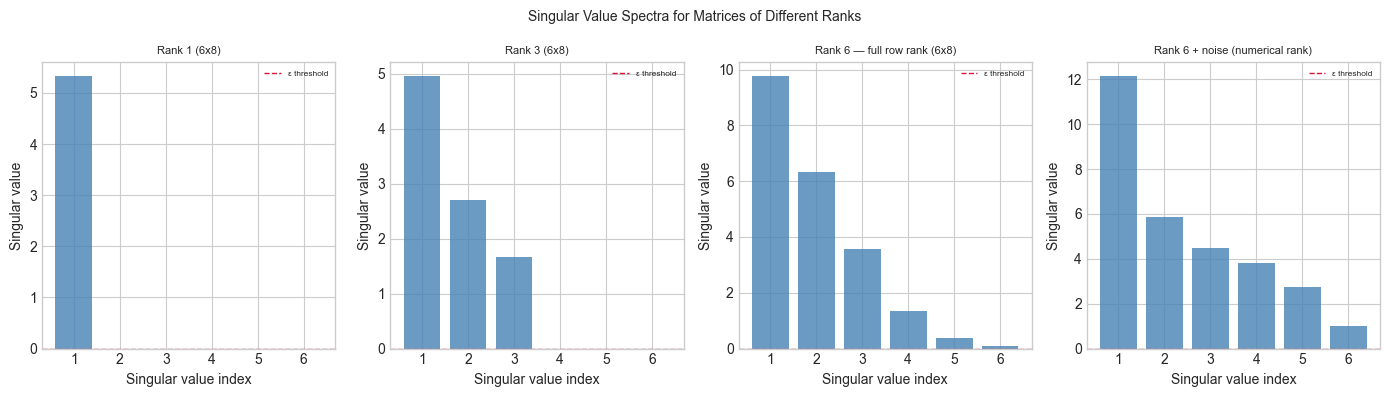

Rank = number of singular values above threshold.
With noise, 'numerical rank' depends on threshold choice.


In [1]:
# --- Visualization: Rank and null space via SVD ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(42)

# Build matrices with known rank
def low_rank_matrix(m, n, rank, noise=0.0, rng=rng):
    """Construct an m x n matrix of given rank with optional noise."""
    U = rng.normal(0, 1, (m, rank))
    V = rng.normal(0, 1, (n, rank))
    A = U @ V.T
    if noise > 0:
        A += noise * rng.normal(0, 1, (m, n))
    return A

# Several matrices with different ranks
configs = [
    (6, 8, 1, 'Rank 1 (6x8)'),
    (6, 8, 3, 'Rank 3 (6x8)'),
    (6, 8, 6, 'Rank 6 — full row rank (6x8)'),
    (6, 8, 6, 'Rank 6 + noise (numerical rank)'),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (m, n, r, title) in zip(axes, configs):
    noise = 0.1 if 'noise' in title else 0.0
    A = low_rank_matrix(m, n, r, noise=noise)
    _, s, _ = np.linalg.svd(A, full_matrices=False)
    ax.bar(range(1, len(s)+1), s, color='steelblue', alpha=0.8)
    ax.axhline(1e-10, color='crimson', ls='--', lw=1, label='ε threshold')
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Singular value index')
    ax.set_ylabel('Singular value')
    ax.legend(fontsize=6)

plt.suptitle('Singular Value Spectra for Matrices of Different Ranks', fontsize=10)
plt.tight_layout()
plt.show()
print("Rank = number of singular values above threshold.")
print("With noise, 'numerical rank' depends on threshold choice.")

## 4. Mathematical Formulation

For $A \in \mathbb{R}^{m \times n}$ with SVD $A = U \Sigma V^\top$:

- **Rank**: $r = \text{rank}(A)$ = number of non-zero singular values
- **Nullity**: $\text{null}(A) = n - r$
- **Rank-Nullity theorem**: $r + (n - r) = n$ ✓

The four fundamental subspaces in terms of SVD:
$$\text{col}(A) = \text{span}(U_r) \subset \mathbb{R}^m, \quad \dim = r$$
$$\text{null}(A) = \text{span}(V_{n-r}) \subset \mathbb{R}^n, \quad \dim = n-r$$
$$\text{row}(A) = \text{span}(V_r) \subset \mathbb{R}^n, \quad \dim = r$$
$$\text{null}(A^\top) = \text{span}(U_{m-r}) \subset \mathbb{R}^m, \quad \dim = m-r$$

where subscripts indicate taking the first $r$ or last $n-r$ columns.

**Solvability of $A\mathbf{x} = \mathbf{b}$:**
- A solution exists if and only if $\mathbf{b} \in \text{col}(A)$
- If a solution exists, it is unique if and only if $\text{null}(A) = \{\mathbf{0}\}$ (i.e., $r = n$)
- If not unique: general solution = particular solution + any vector in $\text{null}(A)$

## 5. Python Implementation

In [2]:
# --- Implementation: Four Fundamental Subspaces via SVD ---

def four_fundamental_subspaces(A, tol=1e-10):
    """
    Compute the four fundamental subspaces of A via SVD.
    
    Args:
        A:   (m, n) matrix
        tol: threshold below which singular values are treated as zero
    
    Returns:
        col_space:       (m, r) basis for column space
        null_space:      (n, n-r) basis for null space
        row_space:       (n, r) basis for row space
        left_null_space: (m, m-r) basis for left null space
        rank:            r
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=True)
    
    r = int(np.sum(s > tol))   # numerical rank
    
    col_space       = U[:, :r]        # first r columns of U
    left_null_space = U[:, r:]        # remaining columns of U
    row_space       = Vt[:r, :].T     # first r rows of Vt transposed
    null_space      = Vt[r:, :].T     # remaining rows of Vt transposed
    
    return col_space, null_space, row_space, left_null_space, r

def numerical_rank(A, tol=1e-10):
    """Numerical rank of A: number of singular values above tol."""
    _, s, _ = np.linalg.svd(A, full_matrices=False)
    return int(np.sum(s > tol))

def nullity(A, tol=1e-10):
    """Nullity = n - rank."""
    return A.shape[1] - numerical_rank(A, tol)

# --- Validate on known matrices ---
# Test 1: rank-2 matrix (outer product of two vectors)
u = np.array([1, 2, 3, 4], dtype=float)
v = np.array([1, 1, 0, 0, 1], dtype=float)
A1 = np.outer(u, v)   # rank 1

# Test 2: general 4x5 rank-3 matrix
A2 = low_rank_matrix(4, 5, 3)

# Test 3: 5x3 full column rank
A3 = rng.normal(0, 1, (5, 3))

for A, name in [(A1, 'Outer product (expected rank=1)'),
                (A2, '4x5 rank-3 matrix'),
                (A3, '5x3 full col rank')]:
    cs, ns, rs, lns, r = four_fundamental_subspaces(A)
    m, n = A.shape
    print(f"\n{name}:")
    print(f"  Shape: {m}x{n},  Rank={r},  Nullity={n-r}")
    print(f"  Rank + Nullity = {r} + {n-r} = {r + (n-r)} (should equal n={n})")
    print(f"  col_space dim: {cs.shape[1]}, null_space dim: {ns.shape[1] if ns.size > 0 else 0}")
    
    # Orthogonality check: col_space ⊥ left_null_space
    if lns.size > 0 and cs.size > 0:
        orth_err = np.abs(cs.T @ lns).max()
        print(f"  Orthogonality (col ⊥ left_null): max error = {orth_err:.2e}")


Outer product (expected rank=1):
  Shape: 4x5,  Rank=1,  Nullity=4
  Rank + Nullity = 1 + 4 = 5 (should equal n=5)
  col_space dim: 1, null_space dim: 4
  Orthogonality (col ⊥ left_null): max error = 2.22e-16

4x5 rank-3 matrix:
  Shape: 4x5,  Rank=3,  Nullity=2
  Rank + Nullity = 3 + 2 = 5 (should equal n=5)
  col_space dim: 3, null_space dim: 2
  Orthogonality (col ⊥ left_null): max error = 2.78e-16

5x3 full col rank:
  Shape: 5x3,  Rank=3,  Nullity=0
  Rank + Nullity = 3 + 0 = 3 (should equal n=3)
  col_space dim: 3, null_space dim: 0
  Orthogonality (col ⊥ left_null): max error = 2.14e-16


## 6. Experiments

In [3]:
# --- Experiment 1: Solvability of Ax = b ---
# Hypothesis: Ax=b is solvable iff b is in the column space of A.
# Try changing: RANK, the RHS vector b

RANK = 2   # <-- try 1, 2, 3
m, n = 4, 5
A = low_rank_matrix(m, n, RANK)
cs, ns, rs, lns, r = four_fundamental_subspaces(A)

# b in column space (solvable)
b_solvable = cs @ rng.normal(0, 1, r)      # linear combo of col space basis

# b not in column space (no solution)
if lns.size > 0:
    b_impossible = lns[:, 0]   # lives in left null space — perpendicular to col space
else:
    b_impossible = rng.normal(0, 1, m)   # random (likely not in col space)

# Check: project b onto col space; if residual is zero, b is in col space
def in_column_space(b, col_space, tol=1e-9):
    """Check if b lies in the span of col_space columns."""
    proj = col_space @ col_space.T @ b
    residual = np.linalg.norm(b - proj)
    return residual < tol, residual

in_cs, res_s = in_column_space(b_solvable, cs)
in_ci, res_i = in_column_space(b_impossible, cs)

print(f"Rank-{RANK} matrix ({m}x{n}):")
print(f"  b_solvable  in col space: {in_cs}  (residual={res_s:.2e})")
print(f"  b_impossible in col space: {in_ci}  (residual={res_i:.2e})")

Rank-2 matrix (4x5):
  b_solvable  in col space: True  (residual=3.38e-16)
  b_impossible in col space: False  (residual=1.00e+00)


Ax_particular - b residual: 7.74e-16


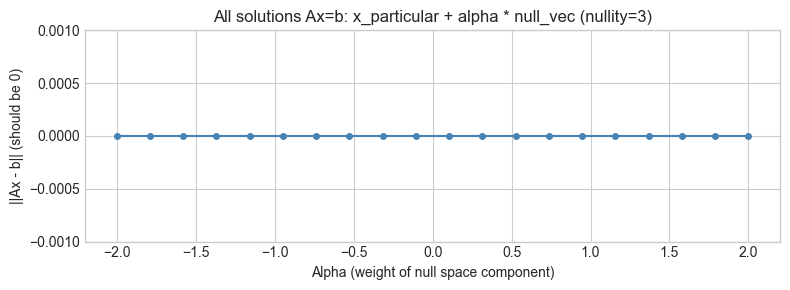

Residual is ~0 for all alpha: infinitely many exact solutions.


In [4]:
# --- Experiment 2: Null Space and Solution Families ---
# Hypothesis: if nullity > 0, there are infinitely many solutions to Ax = b.
# Try changing: RANK_EXP

RANK_EXP = 2   # <-- try 1, 2, 3, 4
m_e, n_e = 4, 5
A_e = low_rank_matrix(m_e, n_e, RANK_EXP)
cs_e, ns_e, _, _, r_e = four_fundamental_subspaces(A_e)

b_e = cs_e @ rng.normal(0, 1, r_e)   # solvable b

# Find a particular solution via least-norm pseudoinverse
# Pseudoinverse via SVD: A+ = V S+ U.T
U_e, s_e, Vt_e = np.linalg.svd(A_e, full_matrices=True)
s_inv = np.where(s_e > 1e-10, 1/s_e, 0)
# Build S+ (m x n)
S_plus = np.zeros((n_e, m_e))
for i in range(min(m_e, n_e)):
    if i < len(s_inv):
        S_plus[i, i] = s_inv[i]
A_pinv = Vt_e.T @ S_plus @ U_e.T
x_particular = A_pinv @ b_e

# Verify: Ax_particular ≈ b
print(f"Ax_particular - b residual: {np.linalg.norm(A_e @ x_particular - b_e):.2e}")

# General solution family: x_particular + alpha * null_vec for each null vector
if ns_e.size > 0:
    ALPHA_VALS = np.linspace(-2, 2, 20)
    null_vec = ns_e[:, 0]
    residuals = [np.linalg.norm(A_e @ (x_particular + a * null_vec) - b_e)
                 for a in ALPHA_VALS]
    
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(ALPHA_VALS, residuals, 'o-', ms=4, color='steelblue')
    ax.set_xlabel('Alpha (weight of null space component)')
    ax.set_ylabel('||Ax - b|| (should be 0)')
    ax.set_title(f'All solutions Ax=b: x_particular + alpha * null_vec (nullity={n_e - r_e})')
    ax.set_ylim(-0.001, max(residuals) * 1.2 + 0.001)
    plt.tight_layout()
    plt.show()
    print("Residual is ~0 for all alpha: infinitely many exact solutions.")

## 7. Exercises

**Easy 1.** For the matrix $A = \begin{pmatrix} 1 & 2 & 3 \\ 2 & 4 & 6 \end{pmatrix}$, compute rank and nullity by inspection. Verify with numpy. *(Expected: rank=1, nullity=2)*

**Easy 2.** Write a function `is_consistent(A, b)` that returns True if $A\mathbf{x} = \mathbf{b}$ has at least one solution. Use SVD to check if $\mathbf{b}$ lies in the column space of $A$.

**Medium 1.** Given a $5 \times 7$ matrix of rank 3, state the dimensions of all four fundamental subspaces. Then construct such a matrix and verify computationally that each basis has the correct dimension and the pair-wise orthogonality conditions hold.

**Medium 2.** The **pseudoinverse** $A^+$ satisfies $AA^+A = A$ and $A^+AA^+ = A^+$. Implement it via SVD and verify these two conditions numerically for a $4 \times 6$ rank-2 matrix.

**Hard.** Prove (computationally) that the column space of $A$ and the left null space of $A$ are orthogonal complements in $\mathbb{R}^m$: their bases together form a complete orthonormal basis for $\mathbb{R}^m$. Verify by showing $[U_r | U_{m-r}]^\top [U_r | U_{m-r}] = I_m$ where $U_r$ is the col-space basis and $U_{m-r}$ is the left null space basis from the full SVD.

## 8. Mini Project

In [5]:
# --- Mini Project: Network Constraint Analysis ---
# Problem: A water distribution network has nodes (junctions) and edges (pipes).
#          The incidence matrix B[e, v] = +1 if edge e leaves node v, -1 if it enters.
#          Flow conservation: B.T @ flow = demand. The rank of B.T determines
#          whether the system is solvable and how many degrees of freedom exist.
# Task: Build a network incidence matrix, analyze its four subspaces,
#       and interpret each subspace in terms of the network.

# Network: 5 nodes, 6 edges
#   0-1, 1-2, 2-3, 3-0, 1-3, 0-2
nodes = 5
edges = [(0,1), (1,2), (2,3), (3,0), (1,3), (0,2), (2,4), (3,4)]
n_edges = len(edges)

# Build incidence matrix B (n_edges x nodes)
B = np.zeros((n_edges, nodes))
for e_idx, (i, j) in enumerate(edges):
    B[e_idx, i] = +1
    B[e_idx, j] = -1

print(f"Incidence matrix B: {B.shape}  ({n_edges} edges x {nodes} nodes)")
print(f"B =\n{B.astype(int)}")

cs, ns, rs, lns, r = four_fundamental_subspaces(B)
print(f"\nRank(B):   {r}")
print(f"Nullity(B): {n_edges - r}  (= number of independent cycles in the network)")
print(f"Left Null Space dim: {lns.shape[1]}  (= number of connected components - 1)")
print(f"\nNull space of B (cycle basis):")
print(f"  Each null space vector represents a circulation (flow around a cycle).")
if ns.size > 0:
    print(ns.round(3))
print(f"\nLeft null space of B:")
print(f"  The vector [1,1,1,...,1]/sqrt(n) is always here (sum of all rows = 0).")
if lns.size > 0:
    print(lns.round(3))

Incidence matrix B: (8, 5)  (8 edges x 5 nodes)
B =
[[ 1 -1  0  0  0]
 [ 0  1 -1  0  0]
 [ 0  0  1 -1  0]
 [-1  0  0  1  0]
 [ 0  1  0 -1  0]
 [ 1  0 -1  0  0]
 [ 0  0  1  0 -1]
 [ 0  0  0  1 -1]]

Rank(B):   4
Nullity(B): 4  (= number of independent cycles in the network)
Left Null Space dim: 4  (= number of connected components - 1)

Null space of B (cycle basis):
  Each null space vector represents a circulation (flow around a cycle).
[[-0.447]
 [-0.447]
 [-0.447]
 [-0.447]
 [-0.447]]

Left null space of B:
  The vector [1,1,1,...,1]/sqrt(n) is always here (sum of all rows = 0).
[[-0.634  0.082 -0.303 -0.003]
 [-0.242 -0.165 -0.358 -0.558]
 [ 0.325  0.31  -0.595 -0.21 ]
 [-0.257  0.666 -0.108 -0.061]
 [-0.391  0.247  0.055  0.555]
 [ 0.377  0.585  0.195 -0.058]
 [-0.191  0.11   0.432 -0.406]
 [ 0.191 -0.11  -0.432  0.406]]


## 9. Chapter Summary & Connections

- The rank of $A$ = number of non-zero singular values = dimension of column space = dimension of row space. Nullity = $n - r$. These sum to $n$ by the Rank-Nullity theorem *(ch173 — SVD)*.
- SVD makes all four fundamental subspaces explicit: $U_r$ spans col$(A)$; $U_{m-r}$ spans left null$(A)$; $V_r$ spans row$(A)$; $V_{n-r}$ spans null$(A)$ *(ch173)*.
- Solvability of $A\mathbf{x}=\mathbf{b}$: exists iff $\mathbf{b} \in \text{col}(A)$; unique iff null$(A) = \{\mathbf{0}\}$.
- These concepts appear every time you analyze a system of equations — in networks, physics, optimization, and machine learning.

**Forward:** This reappears in ch212 (Gradient Descent) when analyzing the geometry of the loss landscape — the null space of the Jacobian determines which parameter directions have zero gradient and governs convergence behavior. It also reappears in ch273 (Regression) when understanding why the normal equations may be singular.

**Backward:** This chapter makes precise what ch161 (Gaussian Elimination) and ch145 (Basis and Dimension) pointed toward. Gaussian elimination finds the rank by counting pivot rows; here we see the same count from SVD.